In [1]:
import numpy as np
import stim, sinter, math
from dataclasses import dataclass
import matplotlib.pyplot as plt
from src.pqubit_error_model import pqubit_error_model
#from src.drifting_pqubit_error_model import drifting_pqubit_error_model
from src.patch import surf_patch

In [2]:
def _rng(seed: int | None) -> np.random.Generator:
    """Create a per-process RNG (reproducible when seed is given)."""
    ss = np.random.SeedSequence() if seed is None else np.random.SeedSequence(seed)
    return np.random.default_rng(ss)

@dataclass(frozen=True)
class DriftParams:
    min_time: float  # seconds
    max_time: float  # seconds
    s: float         # lognormal shape


@dataclass(frozen=True)
class BaseDistParams:
    min_p: float
    max_p: float

def unif_dist(min_val: float, max_val: float):
    """Uniform RV using NumPy Generator; returns an object with .rvs()."""
    class _RV:
        __slots__ = ("min", "max", "rng")
        def __init__(self, min_val, max_val, rng):
            self.min = min_val; self.max = max_val; self.rng = rng
        def rvs(self):
            return float(self.rng.uniform(self.min, self.max))
    return _RV, (min_val, max_val)

In [3]:
# Seed RNG
rng_seed = 0xABC123
rng = _rng(rng_seed)

# Create uniform distribution between min and max error rates
base_params = BaseDistParams(1e-4, 1e-3)
UnifRV, unif_args = unif_dist(base_params.min_p, base_params.max_p)
base_rv = UnifRV(*unif_args, rng) # the RNG

# Init patch
dx=dz=r=5
basis='z'
init_state='0'

test_patch: surf_patch = surf_patch(
    dx,
    dz,
    r,
    basis,
    init_state,
    uniform_error_rate=None # <--- Important! Required to use individual error models
    # (or set this val to use uniform error rates and ignore individual error models)
)

# sample and assign each qubit an error model
for q in test_patch.get_qubits():
    q.set_error_model(
        pqubit_error_model(
            after_clifford_depolarization=base_rv.rvs(),
            before_round_data_depolarization=base_rv.rvs(),
            before_measure_flip_probability=base_rv.rvs(),
            after_reset_flip_probability=base_rv.rvs()
        )
    )

In [11]:
error_map: dict[tuple[int,int], float] = {}
remaining_qubits = set([q.get_id() for q in test_patch.get_qubits()])

x_seat=3


for q1 in test_patch.get_qubits():

    qid1: int = q1.get_id()
    remaining_qubits.remove(qid1)

    for qid2 in remaining_qubits:
        #print(remaining_qubits)

        # note that this can be made asymmetric, but we're
        #  choosing to be symmetric
        q2=test_patch.get_qubit_from_id(qid2)

        x1, y1 = q1.get_pos_x(), q1.get_pos_y()
        x2, y2 = q2.get_pos_x(), q2.get_pos_y()

        if {x1, x2} == {x_seat, x_seat+1}: #and abs(y1-y2)<=1:
            error_map[(qid1,qid2)] = base_rv.rvs()*10
            error_map[(qid2,qid1)] = base_rv.rvs()*10
        else:
            error_map[(qid1,qid2)] = base_rv.rvs()
            error_map[(qid2,qid1)] = base_rv.rvs()



# set the error map for the patch
test_patch.set_coupling_error_map(error_map)

In [12]:
circuit_str: str = test_patch.get_full_circuit()
circuit_stim: stim.Circuit = stim.Circuit(circuit_str)

tasks = [
    sinter.Task(
        circuit=circuit_stim,
        json_metadata={'dx': dx, 'dz': dz, 'r': r},
        detector_error_model=circuit_stim.detector_error_model(
            decompose_errors=True
        )
    )
]

stats: list[sinter.TaskStats] = sinter.collect(
    num_workers=12,
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=100_000,
    max_errors=5,
    print_progress=True,
)

print(f"LER: {stats[0].errors/stats[0].shots:.12f}")

Starting 12 workers...
1 tasks left:
  workers    decoder eta shots_left errors_left json_metadata
       12 pymatching  2m      99999           5 dx=9,dz=9,r=9
1 tasks left:
  workers    decoder eta shots_left errors_left json_metadata
       12 pymatching <1m      90716           5 dx=9,dz=9,r=9
1 tasks left:
  workers    decoder eta shots_left errors_left json_metadata
       12 pymatching <1m      78155           5 dx=9,dz=9,r=9
1 tasks left:
  workers    decoder eta shots_left errors_left json_metadata
       12 pymatching <1m      63148           5 dx=9,dz=9,r=9
1 tasks left:
  workers    decoder eta shots_left errors_left json_metadata
       12 pymatching <1m      54080           5 dx=9,dz=9,r=9
1 tasks left:
  workers    decoder eta shots_left errors_left json_metadata
       12 pymatching <1m      45354           5 dx=9,dz=9,r=9
1 tasks left:
  workers    decoder eta shots_left errors_left json_metadata
       12 pymatching <1m      29345           5 dx=9,dz=9,r=9
1 tasks lef

LER: 0.000000000000


In [13]:
from scipy.stats import truncnorm

circuits = []
metadatas = []

basis='z'
init_state='0'

for d in [5,7,9]:

    dx=dz=r=d

    test_patch: surf_patch = surf_patch(
        dx,
        dz,
        r,
        basis,
        init_state,
        uniform_error_rate=None # <--- Important! Required to use individual error models
        # (or set this val to use uniform error rates and ignore individual error models)
    )

    for distro_width in [0.5,1,1.5,2]:

        for mean in np.logspace(-4,-3,10):

            # mean, std
            metadata = {'d':d, 'mean':mean,'width':distro_width}
            metadatas.append(metadata)

            # sample distribution for all error rates
            n: int = test_patch.get_num_qubits()
            num_1q_error_rates = n*4 # 4 error rates per single qubit
            num_2q_error_rates = np.ceil(n*(n-1)/2) # n choose 2 couplings
            error_rates = truncnorm.rvs(
                0,
                np.inf,
                loc=mean,
                scale=mean*distro_width, # std
                size=int(num_1q_error_rates+num_2q_error_rates)
            )

            # sample and assign each qubit an error model
            for i,q in enumerate(test_patch.get_qubits()):
                error_index=i*4
                q.set_error_model(
                    pqubit_error_model(
                        after_clifford_depolarization=error_rates[error_index],
                        before_round_data_depolarization=error_rates[error_index+1],
                        before_measure_flip_probability=error_rates[error_index+2],
                        after_reset_flip_probability=error_rates[error_index+3]
                    )
                )


            # continue indexing
            error_index = num_1q_error_rates

            # build coupling error map
            error_map: dict[tuple[int,int], float] = {}
            remaining_qubits = set([q.get_id() for q in test_patch.get_qubits()])

            for q1 in test_patch.get_qubits():

                qid1: int = q1.get_id()
                remaining_qubits.remove(qid1)

                for qid2 in remaining_qubits:

                    # note that this can be made asymmetric, but we're
                    #  choosing to be symmetric
                    # note - applying a 5x modifier to the coupling error rates
                    modified_error_rate = error_rates[error_index]*5


                    q2=test_patch.get_qubit_from_id(qid2)

                    x1, y1 = q1.get_pos_x(), q1.get_pos_y()
                    x2, y2 = q2.get_pos_x(), q2.get_pos_y()

                    x_seam = 3.5

                    is_crossing_seam = (x1 - x_seam) * (x2 - x_seam) < 0

                    if is_crossing_seam:
                        error_map[(qid1,qid2)] = modified_error_rate*10
                        error_map[(qid2,qid1)] = modified_error_rate*10
                    else:
                        error_map[(qid1,qid2)] = modified_error_rate
                        error_map[(qid2,qid1)] = modified_error_rate
                        
                    # increment index
                    error_index += 1

            # set the error map for the patch
            test_patch.set_coupling_error_map(error_map)

            # append circuit
            circuits.append(
                stim.Circuit(test_patch.get_full_circuit())
            )

In [14]:
tasks = [
    sinter.Task(
        circuit=circuit,
        json_metadata=metadata,
        detector_error_model=circuit.detector_error_model(
            decompose_errors=True # <--- Important!
        )
    ) for circuit,metadata in zip(circuits,metadatas)
]

stats: list[sinter.TaskStats] = sinter.collect(
    num_workers=12,
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=100_000,
    max_errors=10,
    print_progress=True,
)

Starting 12 workers...
120 tasks left:
  workers    decoder        eta shots_left errors_left json_metadata                            
        1 pymatching          ?     100000          10 d=5,mean=0.0001,width=0.5                
        1 pymatching          ?     100000          10 d=5,mean=0.0001291549665014884,width=0.5 
        1 pymatching          ?     100000          10 d=5,mean=0.0001668100537200059,width=0.5 
        1 pymatching          ?     100000          10 d=5,mean=0.00021544346900318845,width=0.5
        1 pymatching          ?     100000          10 d=5,mean=0.0002782559402207126,width=0.5 
        1 pymatching          ?     100000          10 d=5,mean=0.00035938136638046257,width=0.5
        1 pymatching          ?     100000          10 d=5,mean=0.00046415888336127773,width=0.5
        1 pymatching          ?     100000          10 d=5,mean=0.0005994842503189409,width=0.5 
        1 pymatching [draining]      98703         -16 d=5,mean=0.000774263682681127,wid

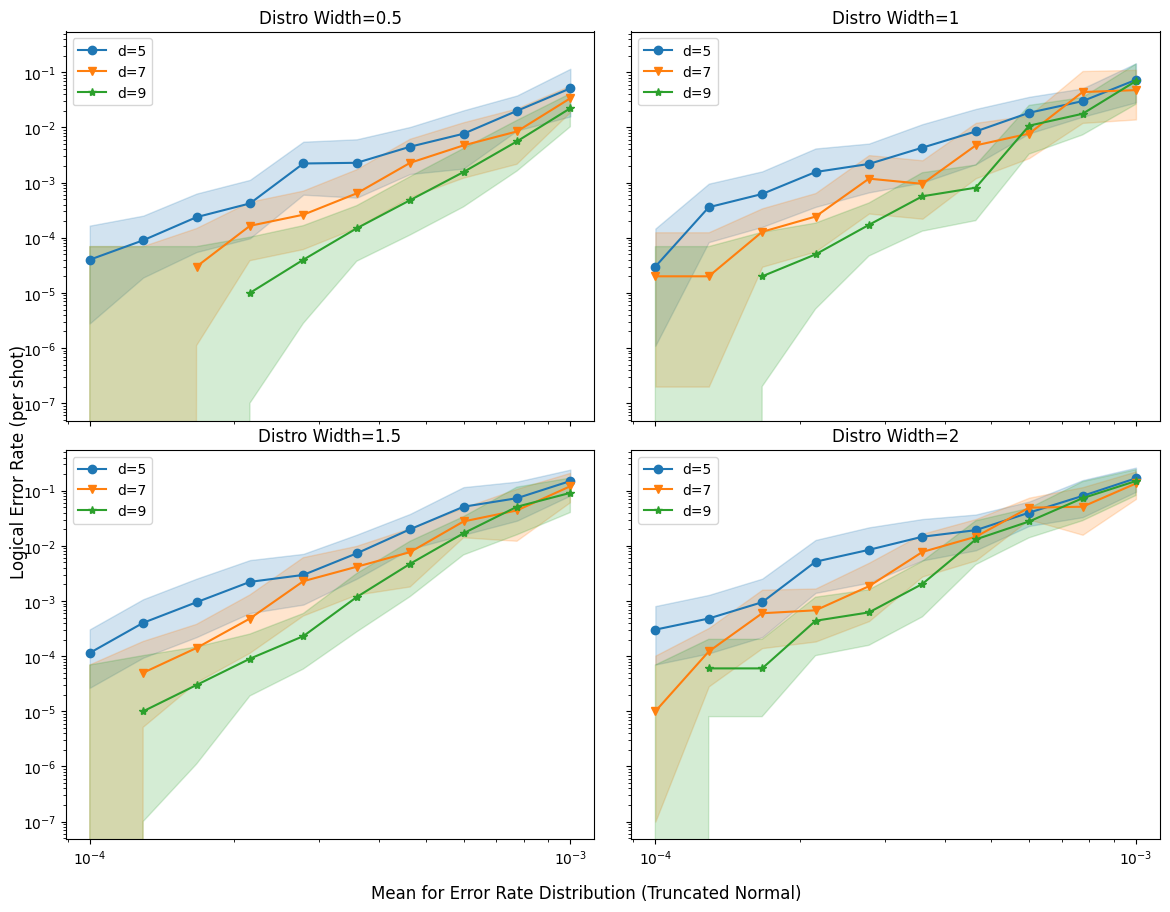

In [15]:
fig,axs = plt.subplots(2,2,figsize=(12,9),sharex=True,sharey=True)
axs = axs.flat # convenience
fig.supxlabel("Mean for Error Rate Distribution (Truncated Normal)")
fig.supylabel("Logical Error Rate (per shot)")
fig.tight_layout()

for ax_i, distro_width in enumerate([0.5,1,1.5,2]):

    ax = axs[ax_i]
    ax.set_title(f"Distro Width={distro_width}")
    ax.set_yscale('log')
    ax.set_xscale('log')
    sinter.plot_error_rate(
        ax=ax,
        stats=stats,
        group_func = lambda stats: f"d={stats.json_metadata['d']}",
        filter_func= lambda stats: stats.json_metadata['width'] == distro_width,
        x_func = lambda stats: stats.json_metadata['mean'],
    )

    ax.legend()